In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym

In [2]:
# Representación visual del grid de Frozen Lake
frozen_lake_grid = np.array([
    ['S', 'F', 'F', 'F'],
    ['F', 'H', 'F', 'H'],
    ['F', 'F', 'F', 'H'],
    ['H', 'F', 'F', 'G']
])

print(frozen_lake_grid)

[['S' 'F' 'F' 'F']
 ['F' 'H' 'F' 'H']
 ['F' 'F' 'F' 'H']
 ['H' 'F' 'F' 'G']]


Número de estados  (observation_space.n): 16
Número de acciones (action_space.n)      : 4

Descripción de los espacios:
  observation_space : Discrete(16)
  action_space      : Discrete(4)

Acciones posibles: 0=Izquierda, 1=Abajo, 2=Derecha, 3=Arriba


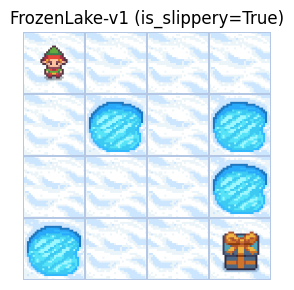

In [3]:
# ─── Task 2.1 ──────────────────────────────────────────────────────────────
# Inicializar el entorno FrozenLake-v1 con hielo resbaladizo (estocástico)
env = gym.make("FrozenLake-v1", is_slippery=True, render_mode="rgb_array")
env.reset()

# Explorar el espacio de estados y acciones
n_states  = env.observation_space.n
n_actions = env.action_space.n

print(f"Número de estados  (observation_space.n): {n_states}")
print(f"Número de acciones (action_space.n)      : {n_actions}")
print()
print("Descripción de los espacios:")
print(f"  observation_space : {env.observation_space}")
print(f"  action_space      : {env.action_space}")
print()
print("Acciones posibles: 0=Izquierda, 1=Abajo, 2=Derecha, 3=Arriba")

# Renderizar el estado inicial
frame = env.render()
plt.figure(figsize=(3, 3))
plt.imshow(frame)
plt.axis("off")
plt.title("FrozenLake-v1 (is_slippery=True)")
plt.tight_layout()
plt.show()

env.close()

In [4]:
# ─── Task 2.1 – Modelado del MDP ────────────────────────────────────────────
# Estados S : 0-15 (izquierda→derecha, arriba→abajo)
# Acciones A: 0=N, 1=E, 2=S, 3=O
n_states  = 16
n_actions = 4
actions   = ['N', 'E', 'S', 'O']

T = np.zeros((n_states, n_actions, n_states))  # Transición T(s, a, s')
R = np.zeros((n_states, n_actions, n_states))  # Recompensa R(s, a, s')

def get_coord(state):
    """Convierte estado (0–15) a (fila, columna)."""
    return state // 4, state % 4

def get_state(row, col):
    """Convierte (fila, columna) a estado (0–15)."""
    return row * 4 + col

def try_move(row, col, direction_id):
    """Calcula nueva posición respetando límites del grid."""
    if   direction_id == 0: row = max(0, row - 1)    # Norte
    elif direction_id == 1: col = min(3, col + 1)    # Este
    elif direction_id == 2: row = min(3, row + 1)    # Sur
    elif direction_id == 3: col = max(0, col - 1)    # Oeste
    return row, col

# Acción → [dirección deseada, desvío 1, desvío 2]
stochastic_directions = {
    0: [0, 1, 3],  # Norte  → puede resbalar a Este u Oeste
    1: [1, 0, 2],  # Este   → puede resbalar a Norte o Sur
    2: [2, 1, 3],  # Sur    → puede resbalar a Este u Oeste
    3: [3, 0, 2],  # Oeste  → puede resbalar a Norte o Sur
}

print("Funciones auxiliares y diccionario de direcciones definidos.")

Funciones auxiliares y diccionario de direcciones definidos.


In [5]:
# ─── Construcción de las matrices T y R ─────────────────────────────────────
for s in range(n_states):
    row, col   = get_coord(s)
    cell_type  = frozen_lake_grid[row, col]

    # Estados terminales: H (agujero) o G (meta)
    # El agente queda atrapado; probabilidad 1 de quedarse, recompensa 0.
    if cell_type in ('H', 'G'):
        for a in range(n_actions):
            T[s, a, s] = 1.0
            R[s, a, s] = 0.0
        continue

    # Estados normales: S o F
    for a in range(n_actions):
        for move_dir in stochastic_directions[a]:
            next_row, next_col = try_move(row, col, move_dir)
            s_prime            = get_state(next_row, next_col)
            next_cell_type     = frozen_lake_grid[next_row, next_col]

            # Cada una de las 3 direcciones ocurre con prob. 1/3.
            # Se usa += para acumular cuando dos direcciones convergen al mismo s'.
            T[s, a, s_prime] += 1 / 3

            # Recompensa = 1 sólo si el estado destino es la meta (G).
            if next_cell_type == 'G':
                R[s, a, s_prime] = 1.0

print("¡Matrices T y R construidas con éxito!")
print(f"  T.shape = {T.shape}  (estados × acciones × estados)")
print(f"  R.shape = {R.shape}  (estados × acciones × estados)")

¡Matrices T y R construidas con éxito!
  T.shape = (16, 4, 16)  (estados × acciones × estados)
  R.shape = (16, 4, 16)  (estados × acciones × estados)
